In [51]:
import pandas as pd
from pprint import pprint
from etna.datasets import TSDataset

pd.options.mode.chained_assignment = None

# Dataset
**1. Утилиты для генерации датасетов:**
- `generate_const_df` — создаёт DataFrame с константными данными.
- `generate_periodic_df` — создаёт DataFrame с периодическими данными.
- `generate_ar_df` — создаёт DataFrame с данными авторегрессионного процесса (AR).
- `generate_from_patterns_df` — создаёт DataFrame по заданным паттернам.
- `generate_hierarchical_df` — создаёт DataFrame с иерархической структурой и данными AR-процесса.

**2. Базовые структуры:**
- `TSDataset` — главный класс для работы с временными рядами.
- `DataFrameFormat` — enum для разных видов `pd.DataFrame`, которые можно использовать (wide/long).
- `HierarchicalStructure` — представляет иерархическую структуру `TSDataset`.

**3. Утилиты для манипуляции данными:**
- `duplicate_data` — размножает датафрейм на все сегменты.
- `set_columns_wide` — подставляет в левый датафрейм колонки со значениями из правого.
- `infer_alignment` — выводит выравнивание для датафрейма.
- `apply_alignment` — применяет выравнивание к датафрейму.
- `make_timestamp_df_from_alignment` — создаёт датафрейм с временными метками по заданному выравниванию.

**4. Утилиты для работы со встроенными датасетами:**
- `load_dataset` — загружает встроенный датасет.


##  1. Утилиты для генерации датасетов

In [5]:
PARAMS = {
    "periods":100,
    "start_time":"2026-09-01",
    "scale":67,
    "n_segments":2,
    "freq":"D",
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    "add_noise":True,
    "sigma":5,
    "random_seed":42
}

### generate_const_df

In [7]:
from etna.datasets import generate_const_df

df = generate_const_df(**PARAMS)
df

,timestamp,segment,target
0,2026-09-01,segment_0,69.483571
1,2026-09-02,segment_0,66.308678
2,2026-09-03,segment_0,70.238443
3,2026-09-04,segment_0,74.615149
4,2026-09-05,segment_0,65.829233
...,...,...,...
195,2026-12-05,segment_1,68.926587
196,2026-12-06,segment_1,62.580713
197,2026-12-07,segment_1,67.768626
198,2026-12-08,segment_1,67.291044


In [8]:
ts = TSDataset(df, "D")
print(f"df:{type(df)}\nts:{type(ts)}")

df:<class 'pandas.core.frame.DataFrame'>
ts:<class 'etna.datasets.tsdataset.TSDataset'>


<Axes: >

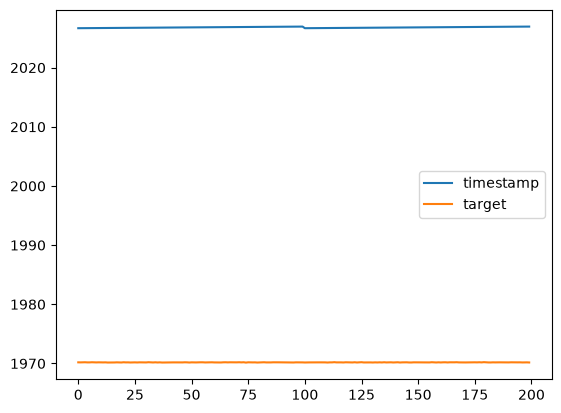

In [9]:
df.plot()

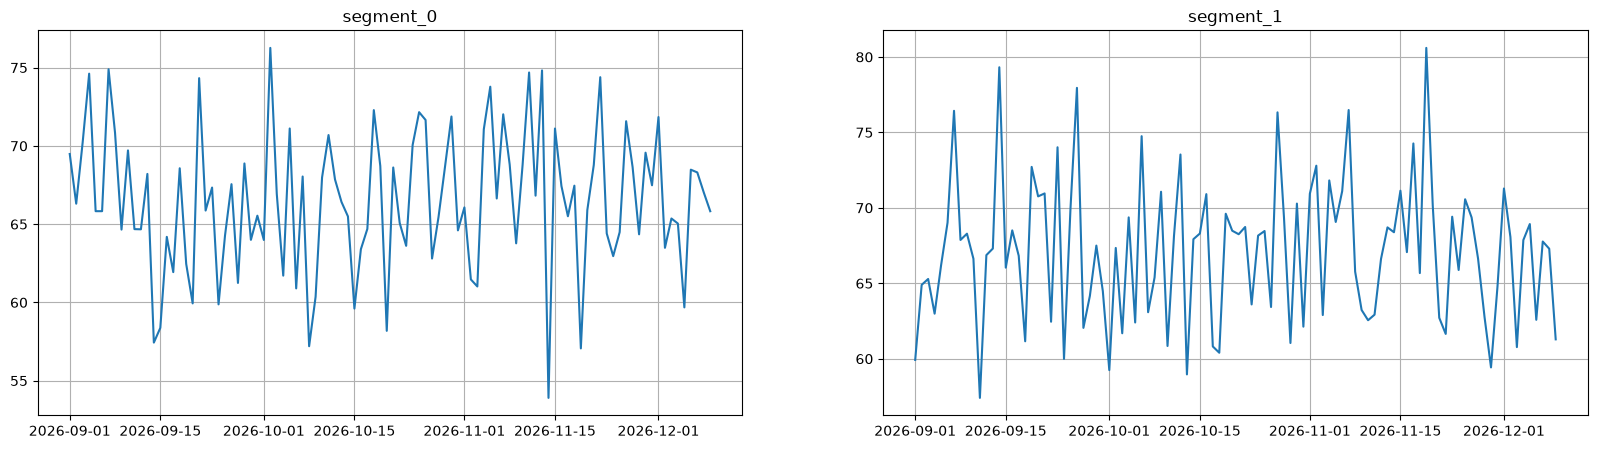

In [10]:
ts.plot()

### generate_periodic_df

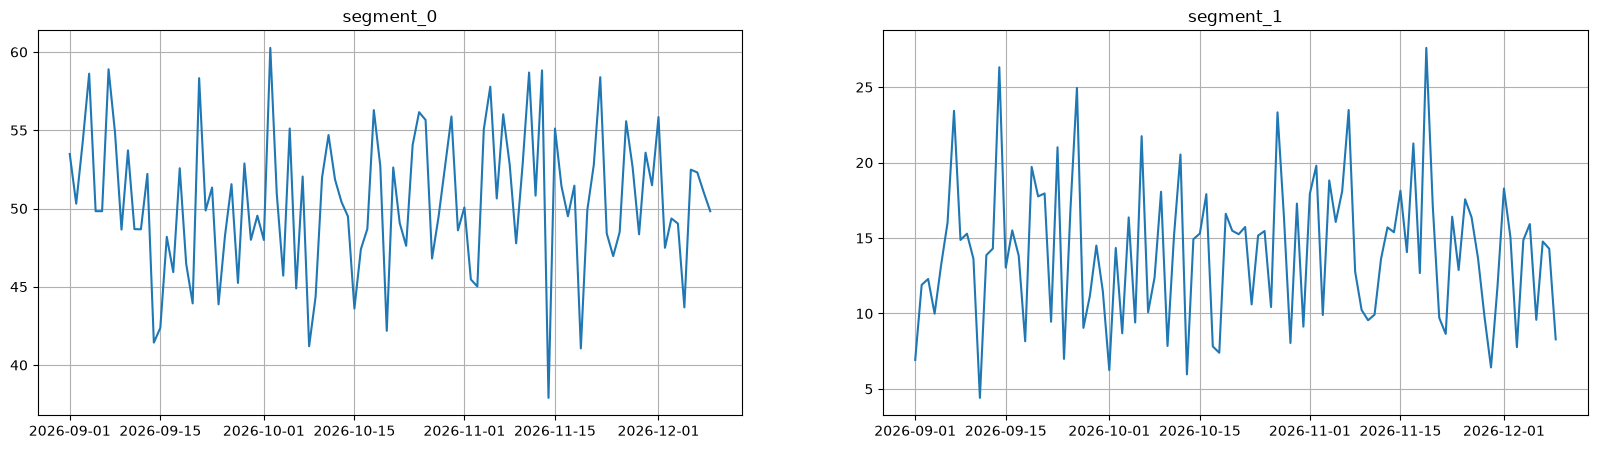

In [12]:
from etna.datasets import generate_periodic_df

df_periodic = generate_periodic_df(**PARAMS) # randint(scale)
ts_periodic = TSDataset(df_periodic, freq="D")
ts_periodic.plot()

### generate_ar_df

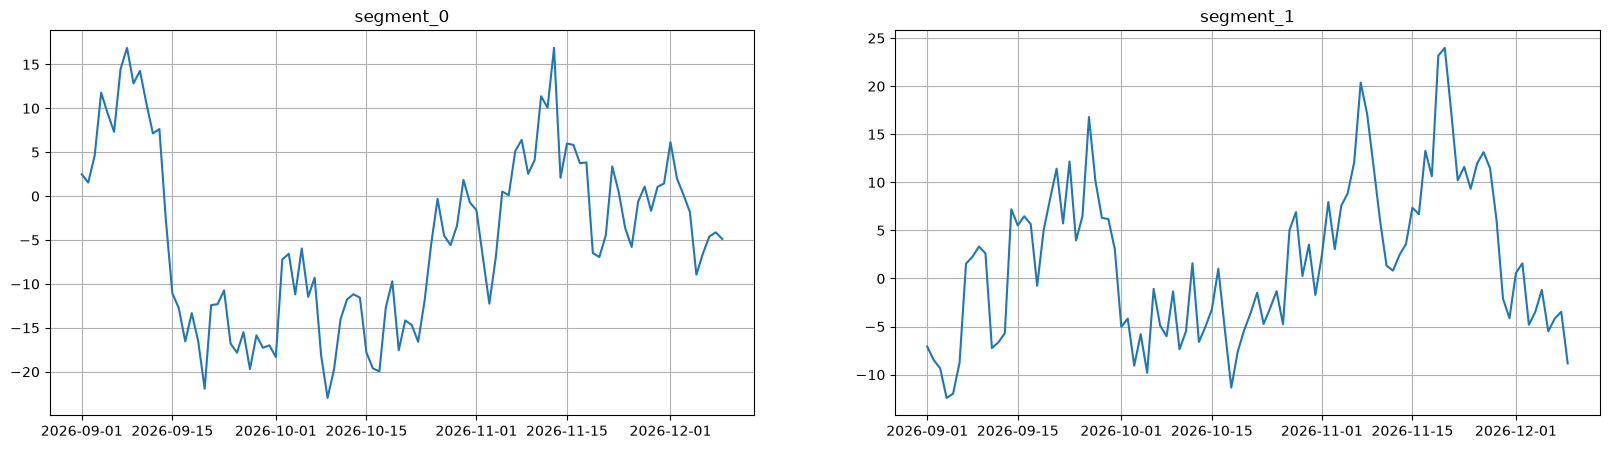

In [14]:
from etna.datasets import generate_ar_df

df_ar = generate_ar_df(
    periods=PARAMS["periods"],
    start_time=PARAMS["start_time"],
    n_segments=PARAMS["n_segments"],
    freq=PARAMS["freq"],
    sigma=PARAMS["sigma"],
    random_seed=PARAMS["random_seed"],

    # Генерирует авторегрессионный процесс (AR), где каждое следующее значение зависит от предыдущего
    # X[t] = ar_coef[0] * X[t-1] + шум.

    # Коэффициент близко к 1 значит, что ряд "помнит" себя надолго. Если сейчас высокое значение, следующее тоже, скорее всего, будет высоким. Получается плавный, "гуляющий" ряд, который может подолгу дрейфовать в одну сторону, прежде чем развернуться.

    # Коэффициент близко к 0 значит, что ряд почти не помнит себя. Текущее значение слабо связано с предыдущим, и в основном определяется случайным шумом. Получается дёрганый ряд без выраженной инерции. Скачет туда-сюда без всякой памяти о прошлом. При ar_coef=0 это уже просто чистый белый шум.
    ar_coef=[0.9], #[0.2]
)

ts_ar = TSDataset(df_ar, freq="D")
ts_ar.plot()

### generate_from_patterns_df

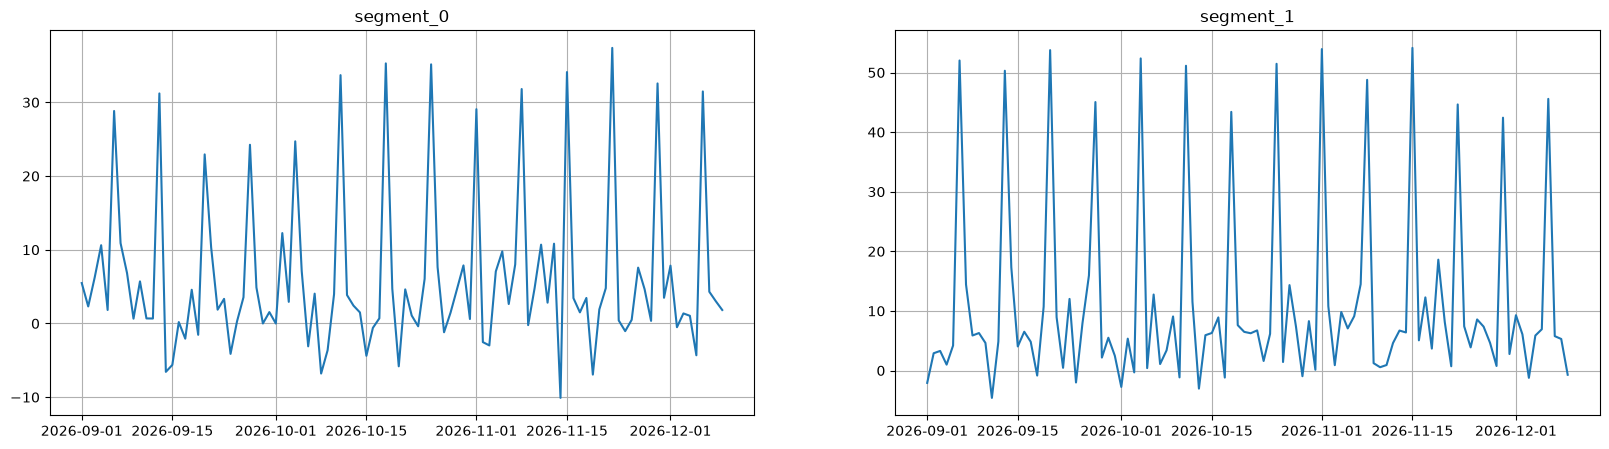

In [16]:
from etna.datasets import generate_from_patterns_df

df_patterns = generate_from_patterns_df(
    periods=PARAMS["periods"],
    start_time=PARAMS["start_time"],
    freq=PARAMS["freq"],
    add_noise=PARAMS["add_noise"],
    sigma=PARAMS["sigma"],
    random_seed=42,

    # Самый общий генератор с полным контролем над формой цикла, на котором построены и generate_const_df, и generate_periodic_df.
    # Здесь задается точная форма повторяющегося паттерна. Пригодится, когда надо
    # - проверить модель на известном "правильном ответе".
    # - смоделировать конкретный реальный сценарий ("продажи растут к выходным и падают в будни").


    patterns=[
    # под start_time="2026-09-01" (вторник): [вт, ср, чт, пт, сб, вс, пн]:
        [3, 3, 3, 3, 3, 30, 3],
        [5, 5, 5, 5, 5, 50, 5],
    ]
)

ts_patterns = TSDataset(df_patterns, freq="D")
ts_patterns.plot()

In [17]:
df_patterns

,timestamp,segment,target
0,2026-09-01,segment_0,5.483571
1,2026-09-02,segment_0,2.308678
2,2026-09-03,segment_0,6.238443
3,2026-09-04,segment_0,10.615149
4,2026-09-05,segment_0,1.829233
...,...,...,...
195,2026-12-05,segment_1,6.926587
196,2026-12-06,segment_1,45.580713
197,2026-12-07,segment_1,5.768626
198,2026-12-08,segment_1,5.291044


### generate_hierarchical_df

In [19]:
from etna.datasets import generate_hierarchical_df

df_h = generate_hierarchical_df(
    periods=PARAMS["periods"],
    start_time=PARAMS["start_time"],
    freq=PARAMS["freq"],
    sigma=PARAMS["sigma"],
    random_seed=PARAMS["random_seed"],


    n_segments=[2, 4],
    ar_coef=[0.9],
)

df_h

,timestamp,target,level_1,level_0
0,2026-09-01,2.483571,l1s0,l0s0
1,2026-09-02,1.543892,l1s0,l0s0
2,2026-09-03,4.627946,l1s0,l0s0
3,2026-09-04,11.780300,l1s0,l0s0
4,2026-09-05,9.431503,l1s0,l0s0
...,...,...,...,...
395,2026-12-05,7.913844,l1s3,l0s1
396,2026-12-06,-1.443213,l1s3,l0s1
397,2026-12-07,5.470470,l1s3,l0s1
398,2026-12-08,4.350724,l1s3,l0s1


In [20]:
df_h.groupby(["level_0", "level_1"]).agg("count")

timestamp  target
level_0 level_1                   
l0s0    l1s0           100     100
        l1s1           100     100
l0s1    l1s2           100     100
        l1s3           100     100

In [21]:
dir(ts)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_cast_index_to_datetime',
 '_cast_segment_to_str',
 '_cast_target_to_float',
 '_check_endings',
 '_check_known_future',
 '_check_regressors',
 '_current_df_exog_level',
 '_current_df_level',
 '_detect_modified_columns',
 '_df',
 '_df_exog',
 '_expand_index',
 '_find_all_borders',
 '_freq',
 '_gather_common_data',
 '_gather_segments_data',
 '_get_dataframe_level',
 '_get_min_max_valid_timestamp',
 '_hierarchical_structure_from_level_columns',
 '_inverse_transform_target_components',
 '_known_future',
 '_merge_exog',
 '_prediction_intervals_names',
 '_prepare_df',
 '_prepare_df_exog',
 '_ra

## 2. Базовые структуры

### `TSDataset`
Основа основ - `TSDataset` с темпоральной индексацией + генераторы синтетики + утилиты выравнивания/загрузки данных. И у этого класса есть:



#### Атрибуты (11) - дают понимание о характеристиках объекта:
- **Форма датасета:**
    - `ts.segments` - список названий сегментов (временных рядов) в датасете
    - `ts.freq` - частота ряда строкой-алиасом pandas
    - `ts.freq_offset` - та же частота, но как объект pd.DateOffset
    - `ts.timestamps` - весь диапазон временных меток датасета
- **Состав признаков:**
    - `ts.features` - список всех признаков (включая target) в датасете
    - `ts.regressors` - список признаков-регрессоров (совпадает с known_future, если они не заданы отдельно)
    - `ts.known_future` - список экзогенных признаков, значения которых известны в будущем (регрессоры)
- **Опциональное:**
    - `ts.target_components_names` - имена компонент декомпозиции target, если она была добавлена
    - `ts.prediction_intervals_names` - имена столбцов с границами доверительных интервалов, если они были добавлены
    - `ts.current_df_level` - уровень иерархии основного df; None, если hierarchical_structure не задан
    - `ts.current_df_exog_level` - уровень иерархии для df_exog; None, если нет ни df_exog, ни hierarchical_structure

#### Методы (31) - дают возможность выполнить действие над объектом.
- **Создание и конвертация формата:**
    - `TSDataset.to_dataset()` - превращает плоский (long) df в df с мультииндексом (wide)
    - `TSDataset.to_flatten()` - превращает wide-df обратно в плоский (long)
    - `ts.to_pandas()` - превращает TSDataset обратно в pandas DataFrame (wide или long)
    - `TSDataset.create_from_misaligned()` - строит TSDataset из рассинхронизированных по времени сегментов
- **Осмотр объекта:**
    - `ts.head()` - первые n строк датасета
    - `ts.tail()` - последние n строк датасета
    - `ts.describe()` - выводит сводную таблицу характеристик датасета
    - `ts.info()` - построчная информация по каждому сегменту
    - `ts.isnull()` - датафрейм-маска: True там, где пропущенные значения
    - `ts.plot()` - визуализирует ряд(ы) target
    - `ts.size()` - размер датасета: (число точек, число сегментов, число признаков)
- **Нарезка по времени/позиции:**
    - `ts.train_test_split()` - делит датасет на train/test с учётом временной структуры
    - `ts.make_future()` - строит датасет для будущего периода на заданный горизонт
    - `ts.tsdataset_idx_slice()` - срез датасета по позиции (индексу), а не по датам
- **Работа с признаками напрямую (без трансформеров):**
    - `ts.add_features_from_pandas()` - добавляет новые признаки в датасет из обычного pandas DataFrame
    - `ts.update_features_from_pandas()` - обновляет значения уже существующих признаков данными из pandas DataFrame
    - `ts.drop_features()` - удаляет указанные признаки из датасета
- **Трансформеры (единый пайплайн препроцессинга):**
    - `ts.fit_transform()` - вычисляет параметры трансформеров и сразу применяет их к датасету
    - `ts.transform()` - применяет уже обученные трансформеры, без повторного fit
    - `ts.inverse_transform()` - применяет обратные преобразования трансформеров (отменяет fit_transform)
- **Иерархия рядов:**
    - `ts.has_hierarchy()` - проверяет, задана ли у датасета иерархическая структура
    - `ts.level_names()` - названия уровней иерархии
    - `ts.get_level_dataset()` - возвращает TSDataset, спроецированный на указанный уровень иерархии
    - `ts.to_hierarchical_dataset()` - автоматически выводит иерархическую структуру из данных
- **Опциональные надстройки — декомпозиция target и доверительные интервалы:**
    - `ts.add_target_components()` - добавляет компоненты декомпозиции target (например, тренд и сезонность отдельно)
    - `ts.get_target_components()` - возвращает датафрейм с компонентами декомпозиции target
    - `ts.drop_target_components()` - удаляет ранее добавленные компоненты декомпозиции target
    - `ts.add_prediction_intervals()` - добавляет столбцы с границами доверительных интервалов прогноза
    - `ts.get_prediction_intervals()` - возвращает датафрейм с границами доверительных интервалов
    - `ts.drop_prediction_intervals()` - удаляет ранее добавленные столбцы доверительных интервалов
- **Интеграция с другими библиотеками:**
    - `ts.to_torch_dataset()` - превращает датасет в PyTorch Dataset для обучения нейросетей

#### Методы конвертации

In [22]:
df_long = df.copy()
print(type(df_long))
df_long

<class 'pandas.core.frame.DataFrame'>


,timestamp,segment,target
0,2026-09-01,segment_0,69.483571
1,2026-09-02,segment_0,66.308678
2,2026-09-03,segment_0,70.238443
3,2026-09-04,segment_0,74.615149
4,2026-09-05,segment_0,65.829233
...,...,...,...
195,2026-12-05,segment_1,68.926587
196,2026-12-06,segment_1,62.580713
197,2026-12-07,segment_1,67.768626
198,2026-12-08,segment_1,67.291044


In [23]:
df_wide = TSDataset.to_dataset(df)
print(type(df_wide))
df_wide

<class 'pandas.core.frame.DataFrame'>


segment,segment_0,segment_1
feature,target,target
timestamp,,
2026-09-01,69.483571,59.923146
2026-09-02,66.308678,64.896773
2026-09-03,70.238443,65.286427
2026-09-04,74.615149,62.988614
2026-09-05,65.829233,66.193571
...,...,...
2026-12-05,59.682425,68.926587
2026-12-06,68.480601,62.580713


In [24]:
df_long2 = TSDataset.to_flatten(df_wide)
print(type(df_long2))
df_long2

<class 'pandas.core.frame.DataFrame'>


,timestamp,segment,target
0,2026-09-01,segment_0,69.483571
1,2026-09-02,segment_0,66.308678
2,2026-09-03,segment_0,70.238443
3,2026-09-04,segment_0,74.615149
4,2026-09-05,segment_0,65.829233
...,...,...,...
195,2026-12-05,segment_1,68.926587
196,2026-12-06,segment_1,62.580713
197,2026-12-07,segment_1,67.768626
198,2026-12-08,segment_1,67.291044


In [25]:
ts_wide = TSDataset(df_long, freq="D")
print(type(ts_wide))
ts_wide

<class 'etna.datasets.tsdataset.TSDataset'>


segment,segment_0,segment_1
feature,target,target
timestamp,,
2026-09-01,69.483571,59.923146
2026-09-02,66.308678,64.896773
2026-09-03,70.238443,65.286427
2026-09-04,74.615149,62.988614
2026-09-05,65.829233,66.193571
...,...,...
2026-12-05,59.682425,68.926587
2026-12-06,68.480601,62.580713


In [26]:
ts_wide.to_pandas(flatten=True) # False

,timestamp,segment,target
0,2026-09-01,segment_0,69.483571
1,2026-09-02,segment_0,66.308678
2,2026-09-03,segment_0,70.238443
3,2026-09-04,segment_0,74.615149
4,2026-09-05,segment_0,65.829233
...,...,...,...
195,2026-12-05,segment_1,68.926587
196,2026-12-06,segment_1,62.580713
197,2026-12-07,segment_1,67.768626
198,2026-12-08,segment_1,67.291044


#### Методы нарезки по времени

In [27]:
ts_train, ts_test = ts.train_test_split(
    # если одновременно заданы и test_size, и явные test_start/test_end, которые ему противоречат,
    # то test_size молча игнорируется, побеждают явные даты.
    train_start="2026-09-01", train_end="2026-11-30",
    # test_start="2026-11-08", test_end="2026-12-09",
    # test_size=5
)

In [28]:
ts_train

segment,segment_0,segment_1
feature,target,target
timestamp,,
2026-09-01,69.483571,59.923146
2026-09-02,66.308678,64.896773
2026-09-03,70.238443,65.286427
2026-09-04,74.615149,62.988614
2026-09-05,65.829233,66.193571
...,...,...
2026-11-26,71.577011,69.366188
2026-11-27,68.643756,66.635855


In [29]:
ts_test

segment,segment_0,segment_1
feature,target,target
timestamp,,
2026-12-01,71.843225,71.281994
2026-12-02,63.489735,68.070469
2026-12-03,65.361689,60.771306
2026-12-04,65.039459,67.865905
2026-12-05,59.682425,68.926587
2026-12-06,68.480601,62.580713
2026-12-07,68.305276,67.768626
2026-12-08,67.025567,67.291044


In [30]:
ts_train.make_future(
    future_steps=8,
    # tail_steps=0
)

segment,segment_0,segment_1
feature,target,target
timestamp,,
2026-12-01,NaN,NaN
2026-12-02,NaN,NaN
2026-12-03,NaN,NaN
2026-12-04,NaN,NaN
2026-12-05,NaN,NaN
2026-12-06,NaN,NaN
2026-12-07,NaN,NaN
2026-12-08,NaN,NaN


#### Экзогенные переменные

In [31]:
# основной ряд
df_main_long = generate_const_df(**PARAMS)
df_main_wide = TSDataset.to_dataset(df_main_long)

# экзогенный ряд
exog_params = {**PARAMS, "periods": PARAMS["periods"] + 10}  # +10 дней запаса в будущее
df_exog_long = generate_periodic_df(**exog_params).rename(columns={"target": "my_regressor"})
df_exog_wide = TSDataset.to_dataset(df_exog_long)

# собираем
ts = TSDataset(
    df_main_wide,
    freq=PARAMS["freq"],
    df_exog=df_exog_wide,
    known_future=["my_regressor"],
)

ts
# ts.features     # ['my_regressor', 'target']
# ts.regressors   # ['my_regressor']
# ts.known_future # ['my_regressor']

segment       segment_0               segment_1           
feature    my_regressor     target my_regressor     target
timestamp                                                 
2026-09-01    53.483571  69.483571     4.406144  59.923146
2026-09-02    50.308678  66.308678    13.867431  64.896773
2026-09-03    54.238443  70.238443    14.301151  65.286427
2026-09-04    58.615149  74.615149    26.316211  62.988614
2026-09-05    49.829233  65.829233    13.038195  66.193571
...                 ...        ...          ...        ...
2026-12-05    43.682425  59.682425     9.310875  68.926587
2026-12-06    52.480601  68.480601    16.575176  62.580713
2026-12-07    52.305276  68.305276    16.568930  67.768626
2026-12-08    51.025567  67.025567    16.575238  67.291044
2026-12-09    49.827064  65.827064    33.263657  61.285149

[100 rows x 4 columns]

### `DataFrameFormat.determine`

In [32]:
from etna.datasets import DataFrameFormat

print(DataFrameFormat.determine(df))       # long - как вернул generate_const_df
print(DataFrameFormat.determine(df_wide))  # wide - после TSDataset.to_dataset()

DataFrameFormat.long
DataFrameFormat.wide


### `HierarchicalStructure`

In [34]:
from etna.datasets import HierarchicalStructure

level_structure = {
    "total": ["X", "Y"],
    "X": ["a", "b"],
    "Y": ["c", "d"],
}

hs = HierarchicalStructure(level_structure=level_structure)

# Делаем 4 сегмента по числу листьев (a, b, c, d)
df_raw = generate_ar_df(periods=100, start_time="2026-09-01", n_segments=4, freq="D")

# переименовываем сегменты под нашу иерархию
rename_map = {
    "segment_0": "a",
    "segment_1": "b",
    "segment_2": "c",
    "segment_3": "d"
}
df_raw["segment"] = df_raw["segment"].map(rename_map)

ts_h = TSDataset(df_raw, freq="D", hierarchical_structure=hs)

ts_h

segment,a,b,c,d
feature,target,target,target,target
timestamp,,,,
2026-09-01,1.624345,-0.447129,-0.400878,2.065783
2026-09-02,1.012589,0.777379,0.423127,0.594626
2026-09-03,0.484417,1.180871,-0.139178,-0.235546
2026-09-04,-0.588551,1.774449,1.815700,-1.116123
2026-09-05,0.276856,0.679537,0.483748,-1.395221
...,...,...,...,...
2026-12-05,6.280511,12.401483,0.149632,-3.158938
2026-12-06,5.936657,13.003802,0.566934,-5.032099


In [35]:
ts_h.has_hierarchy()

True

In [36]:
ts_h.level_names()

['level_0', 'level_1', 'level_2']

In [37]:
ts_h.get_level_dataset(target_level="level_0")

segment,total
feature,target
timestamp,
2026-09-01,2.842122
2026-09-02,2.807722
2026-09-03,1.290564
2026-09-04,1.885475
2026-09-05,0.044921
...,...
2026-12-05,15.672687
2026-12-06,14.475293


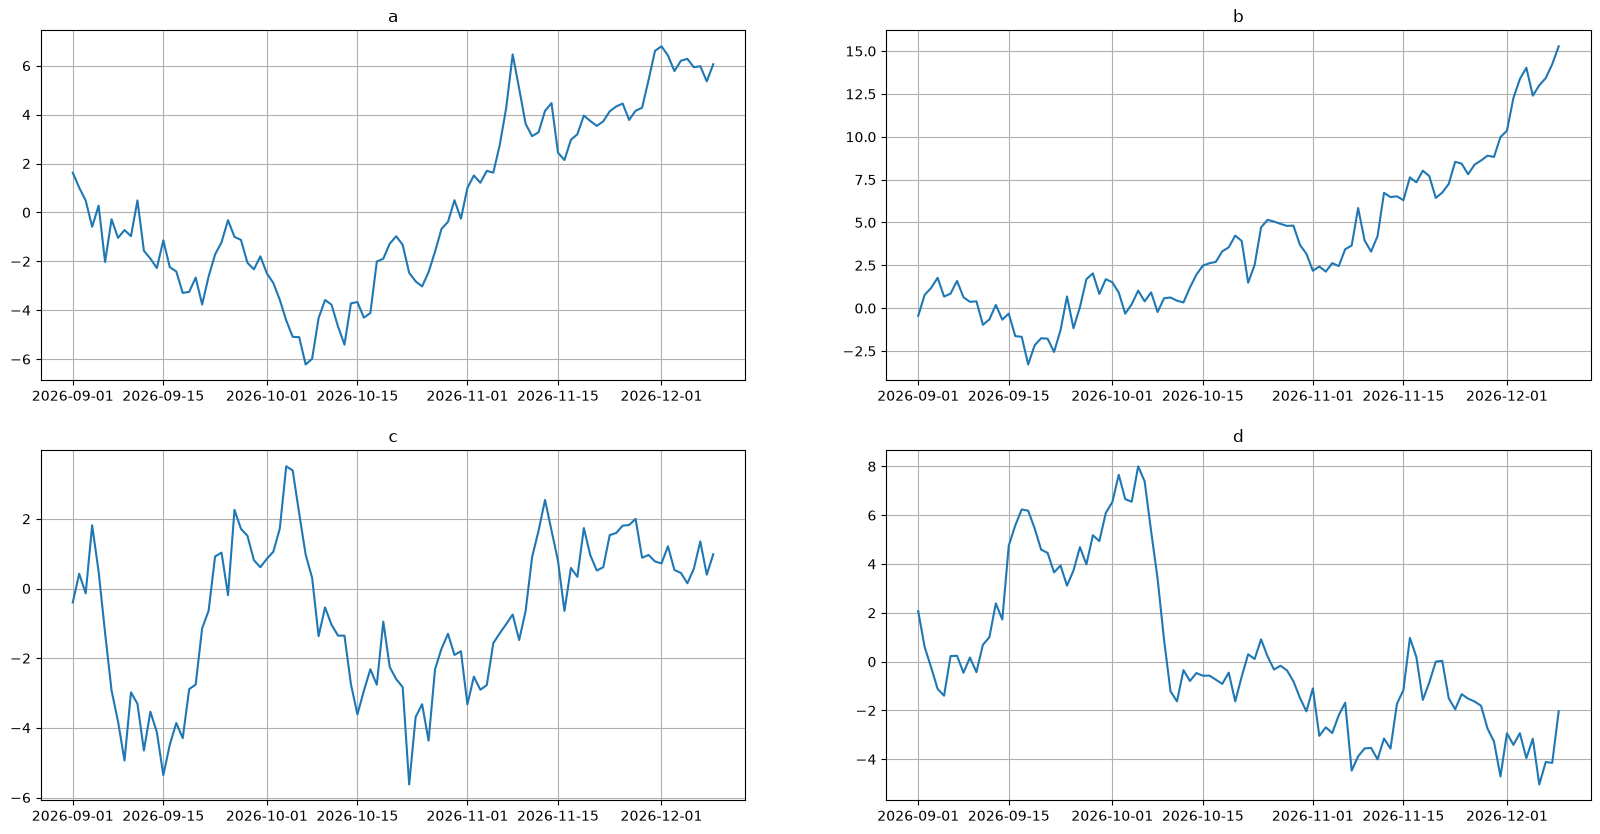

In [38]:
ts_h.plot()

## 3. Утилиты для манипуляции данными

### `duplicate_data`

In [39]:
# Один общий признак на все сегменты (например, флаг "пятница 13-е") - считаем один раз,
# не привязываясь к сегменту, а потом размножаем на нужные сегменты

from etna.datasets import duplicate_data

df = generate_const_df(**PARAMS)

friday_13 = "2026-11-13"

timestamp = df["timestamp"].unique()
df_flag_raw = pd.DataFrame({
    "timestamp": timestamp,
    "is_friday_13": timestamp == pd.Timestamp(friday_13),
})

df_flag_duplicated = duplicate_data(df_flag_raw, segments=df["segment"].unique(), format="wide")
df_flag_duplicated

segment,segment_0,segment_1
feature,is_friday_13,is_friday_13
timestamp,,
2026-09-01,False,False
2026-09-02,False,False
2026-09-03,False,False
2026-09-04,False,False
2026-09-05,False,False
...,...,...
2026-12-05,False,False
2026-12-06,False,False


### `set_columns_wide`

In [40]:
# Подменяем target у segment_0 в df_wide значениями из другого сгенерированного ряда (df_periodic)

from etna.datasets import set_columns_wide

df_periodic_wide = TSDataset.to_dataset(df_periodic)

df_patched = set_columns_wide(
    df_left=df_wide,
    df_right=df_periodic_wide,
    segments_left=["segment_0"],
    segments_right=["segment_0"],
)
df_patched

segment,segment_0,segment_1
feature,target,target
timestamp,,
2026-09-01,53.483571,59.923146
2026-09-02,50.308678,64.896773
2026-09-03,54.238443,65.286427
2026-09-04,58.615149,62.988614
2026-09-05,49.829233,66.193571
...,...,...
2026-12-05,43.682425,68.926587
2026-12-06,52.480601,62.580713


### `infer_alignment` & `apply_alignment`

In [41]:
from etna.datasets import infer_alignment, apply_alignment

# Собираем "кривой" датасет
df_1 = generate_periodic_df(periods=10, start_time="2026-09-01", add_noise=True, sigma=2)
df_1["segment"] = "segment_A"

df_2 = generate_periodic_df(periods=7, start_time="2026-09-03", add_noise=True, sigma=2)
df_2["segment"] = "segment_B"

df_3 = generate_periodic_df(periods=7, start_time="2026-09-05", add_noise=True, sigma=2)
df_3["segment"] = "segment_C"

df = pd.concat([df_1, df_2, df_3], ignore_index=True)
df

,timestamp,segment,target
0,2026-09-01,segment_A,8.248691
1,2026-09-02,segment_A,3.776487
2,2026-09-03,segment_A,3.943656
3,2026-09-04,segment_A,2.854063
4,2026-09-05,segment_A,6.730815
5,2026-09-06,segment_A,0.396923
6,2026-09-07,segment_A,8.489624
7,2026-09-08,segment_A,3.477586
8,2026-09-09,segment_A,5.638078
9,2026-09-10,segment_A,4.501259


In [42]:
# последняя (самая поздняя) дата, которая есть в данных для каждого сегмента
alignment = infer_alignment(df)
pprint(alignment)

{'segment_A': Timestamp('2026-09-10 00:00:00'),
 'segment_B': Timestamp('2026-09-09 00:00:00'),
 'segment_C': Timestamp('2026-09-11 00:00:00')}


In [43]:
df_aligned = apply_alignment(df, alignment, original_timestamp_name="real_date")
df_aligned

,real_date,segment,target,timestamp
0,2026-09-01,segment_A,8.248691,-9
1,2026-09-02,segment_A,3.776487,-8
2,2026-09-03,segment_A,3.943656,-7
3,2026-09-04,segment_A,2.854063,-6
4,2026-09-05,segment_A,6.730815,-5
5,2026-09-06,segment_A,0.396923,-4
6,2026-09-07,segment_A,8.489624,-3
7,2026-09-08,segment_A,3.477586,-2
8,2026-09-09,segment_A,5.638078,-1
9,2026-09-10,segment_A,4.501259,0


In [44]:
ts_aligned = TSDataset(df_aligned, freq=None)
ts_aligned

segment    segment_A            segment_B            segment_C          
feature    real_date    target  real_date    target  real_date    target
timestamp                                                               
-9        2026-09-01  8.248691        NaT       NaN        NaT       NaN
-8        2026-09-02  3.776487        NaT       NaN        NaT       NaN
-7        2026-09-03  3.943656        NaT       NaN        NaT       NaN
-6        2026-09-04  2.854063 2026-09-03  8.248691 2026-09-05  8.248691
-5        2026-09-05  6.730815 2026-09-04  3.776487 2026-09-06  3.776487
-4        2026-09-06  0.396923 2026-09-05  3.943656 2026-09-07  3.943656
-3        2026-09-07  8.489624 2026-09-06  2.854063 2026-09-08  2.854063
-2        2026-09-08  3.477586 2026-09-07  6.730815 2026-09-09  6.730815
-1        2026-09-09  5.638078 2026-09-08  0.396923 2026-09-10  0.396923
 0        2026-09-10  4.501259 2026-09-09  8.489624 2026-09-11  8.489624

In [45]:
# А можно и через один вызов `create_from_misaligned` получить аналогичный результат.
# И это сразу будет etna.datasets.tsdataset.TSDataset
ts_misaligned = TSDataset.create_from_misaligned(df, freq="D")
ts_misaligned

segment            segment_A                    segment_B            \
feature   external_timestamp    target external_timestamp    target   
timestamp                                                             
-9                2026-09-01  8.248691         2026-08-31       NaN   
-8                2026-09-02  3.776487         2026-09-01       NaN   
-7                2026-09-03  3.943656         2026-09-02       NaN   
-6                2026-09-04  2.854063         2026-09-03  8.248691   
-5                2026-09-05  6.730815         2026-09-04  3.776487   
-4                2026-09-06  0.396923         2026-09-05  3.943656   
-3                2026-09-07  8.489624         2026-09-06  2.854063   
-2                2026-09-08  3.477586         2026-09-07  6.730815   
-1                2026-09-09  5.638078         2026-09-08  0.396923   
 0                2026-09-10  4.501259         2026-09-09  8.489624   

segment            segment_C            
feature   external_timestamp    target  
timestamp                               
-9                2026-09-02       NaN  
-8                2026-09-03       NaN  
-7                2026-09-04       NaN  
-6                2026-09-05  8.248691  
-5                2026-09-06  3.776487  
-4                2026-09-07  3.943656  
-3                2026-09-08  2.854063  
-2                2026-09-09  6.730815  
-1                2026-09-10  0.396923  
 0                2026-09-11  8.489624

### `make_timestamp_df_from_alignment`

In [50]:
# Продолжает синтетическую ось за пределы 0 (в будущее) и переводим позиции обратно в реальные даты

from etna.datasets import make_timestamp_df_from_alignment

pprint(alignment)

future_real_dates = make_timestamp_df_from_alignment(
    alignment, start=1, periods=3, freq="D", timestamp_name="real_date"
)

future_real_dates

{'segment_A': Timestamp('2026-09-10 00:00:00'),
 'segment_B': Timestamp('2026-09-09 00:00:00'),
 'segment_C': Timestamp('2026-09-11 00:00:00')}


,segment,timestamp,real_date
0,segment_A,1,2026-09-11
1,segment_A,2,2026-09-12
2,segment_A,3,2026-09-13
0,segment_B,1,2026-09-10
1,segment_B,2,2026-09-11
2,segment_B,3,2026-09-12
0,segment_C,1,2026-09-12
1,segment_C,2,2026-09-13
2,segment_C,3,2026-09-14


## Утилиты для работы со встроенными датасетами

### `load_dataset`

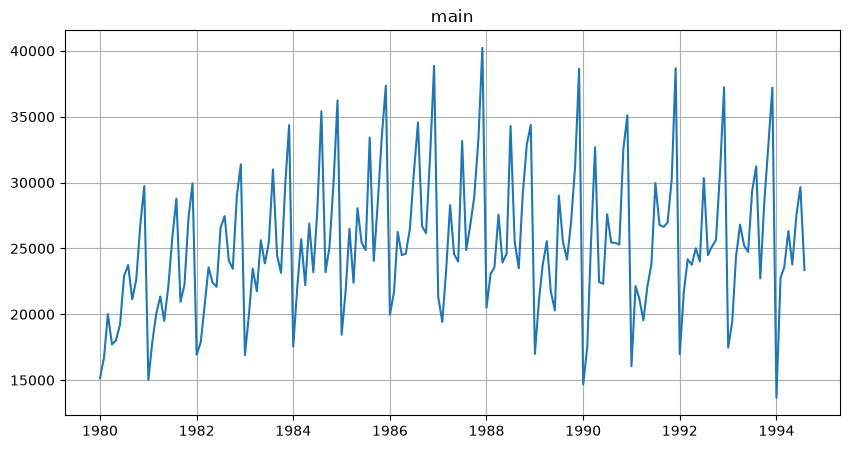

In [49]:
from etna.datasets import load_dataset

# https://docs.etna.ai/stable/internal_datasets.html#internal-datasets
ts = load_dataset(name="australian_wine_sales_monthly")
ts.plot()